# Лабораторная работа: Генетические алгоритмы

---
## Часть 1: Настройка окружения и тестовые функции

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [91]:
def sphere(individual):
    """Sphere: глобальный минимум в 0, f(0)=0"""
    return np.sum(individual**2)

def rastrigin(individual):
    """Rastrigin: многомодальная, минимум f(0)=0"""
    n = len(individual)
    return 10*n + np.sum(individual**2 - 10*np.cos(2*np.pi*individual))

def ackley(individual):
    """Ackley: многомодальная с плоским внешним регионом, минимум f(0)=0"""
    n = len(individual)
    a, b, c = 20, 0.2, 2*np.pi
    return -a*np.exp(-b*np.sqrt(np.sum(individual**2)/n)) - np.eindividualp(np.sum(np.cos(c*individual))/n) + a + np.e

def schwefel(individual):
    """Schwefel: обманчивая функция с ложными минимумами"""
    n = len(individual)
    return 418.9829*n - np.sum(individual * np.sin(np.sqrt(np.abs(individual))))

def himmelblau(individual):
    """Himmelblau: 4 одинаковых минимума, f=0"""
    return (individual[0]**2 + individual[1] - 11)**2 + (individual[0] + individual[1]**2 - 7)**2

def rosenbrock(individual):
    """Rosenbrock (banana): узкая долина, минимум f(1,1)=0"""
    return np.sum(100*(individual[1:] - individual[:-1]**2)**2 + (1 - individual[:-1])**2)

def eggholder(individual):
    """Eggholder: сложный ландшафт с множеством локальных минимумов"""
    individual_1, individual_2 = individual[0], individual[1]
    t1 = -(individual_2 + 47) * np.sin(np.sqrt(np.abs(individual_2 + individual_1/2 + 47)))
    t2 = -individual_1 * np.sin(np.sqrt(np.abs(individual_1 - (individual_2 + 47))))
    return t1 + t2

def griewank(x):
    """Griewank: многомодальная, минимум f(0)=0"""
    i = np.arange(1, len(x)+1)
    return np.sum(x**2)/4000 - np.prod(np.cos(x/np.sqrt(i))) + 1

def michalewicz(x, m=10):
    """Michalewicz: n! локальных минимумов"""
    i = np.arange(1, len(x)+1)
    return -np.sum(np.sin(x) * np.sin(i*x**2/np.pi)**(2*m))

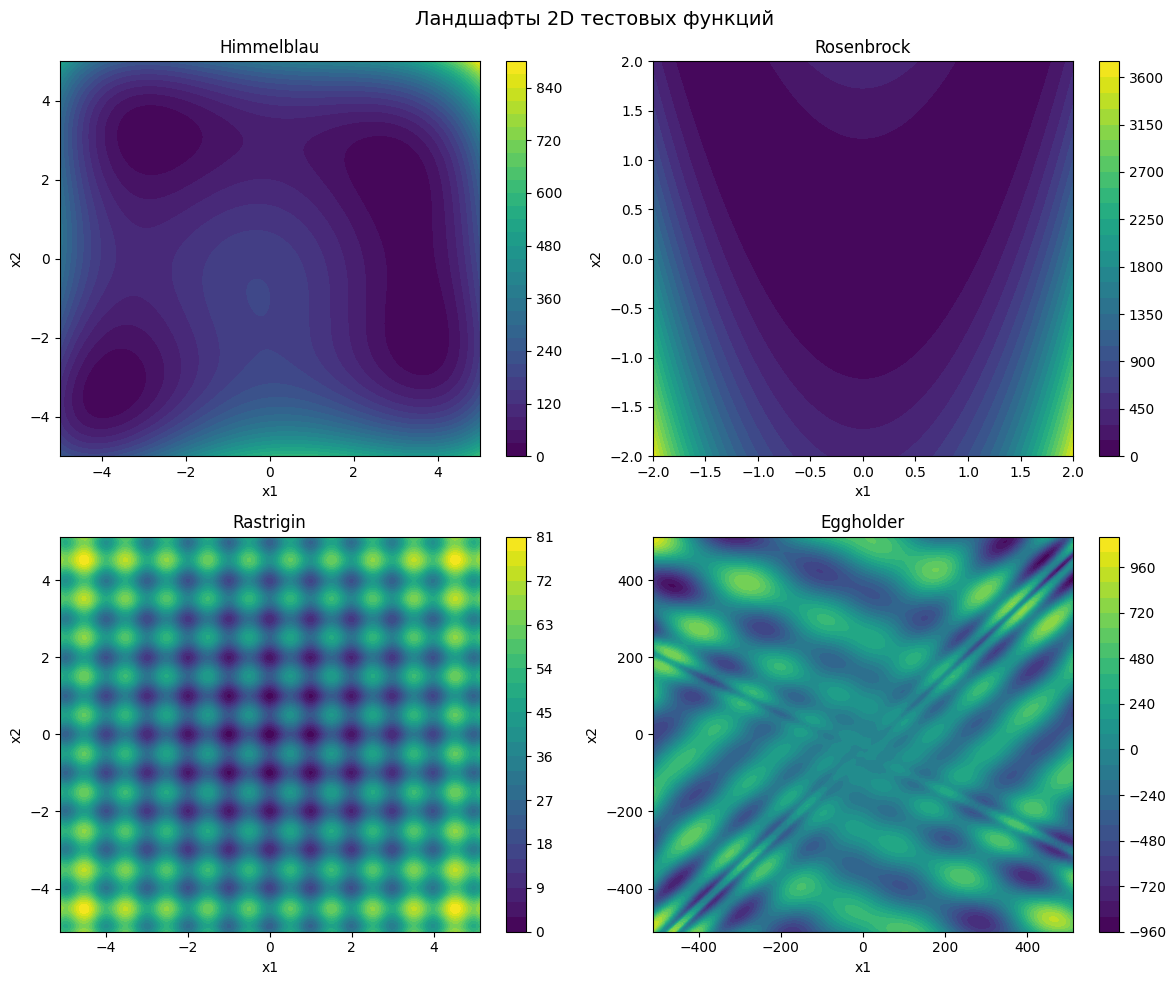

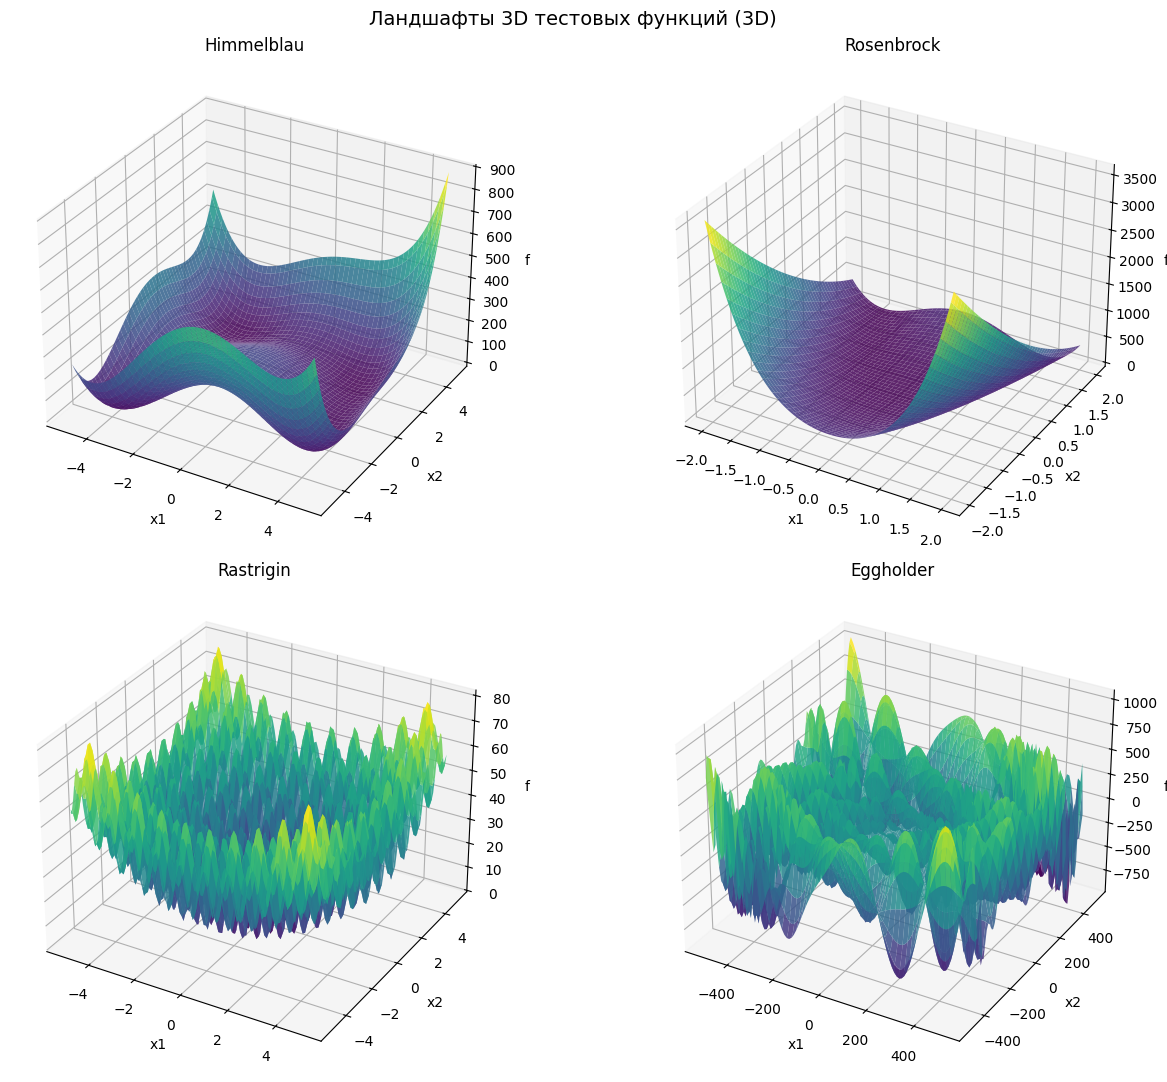

In [92]:
# Визуализация тестовых функций
from mpl_toolkits.mplot3d import Axes3D

funcs_2d = {
    'Himmelblau': (himmelblau, (-5, 5)),
    'Rosenbrock': (rosenbrock, (-2, 2)),
    'Rastrigin':  (lambda x: rastrigin(x), (-5.12, 5.12)),
    'Eggholder':  (eggholder, (-512, 512)),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, (func, (lo, hi))) in zip(axes.flat, funcs_2d.items()):
    x1 = np.linspace(lo, hi, 200)
    x2 = np.linspace(lo, hi, 200)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.array([[func(np.array([xi, xj])) for xi in x1] for xj in x2])
    cp = ax.contourf(X1, X2, Z, levels=30, cmap='viridis')
    plt.colorbar(cp, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')

plt.suptitle('Ландшафты 2D тестовых функций', fontsize=14)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(14, 11))
for i, (name, (func, (lo, hi))) in enumerate(funcs_2d.items(), 1):
    x1 = np.linspace(lo, hi, 100)
    x2 = np.linspace(lo, hi, 100)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.array([[func(np.array([xi, xj])) for xi in x1] for xj in x2])

    ax = fig.add_subplot(2, 2, i, projection='3d')
    ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.85, linewidth=0)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('f')
    ax.view_init(elev=30, azim=-60)

plt.suptitle('Ландшафты 3D тестовых функций (3D)', fontsize=14)
plt.tight_layout()
plt.show()

**Вывод** функции существенно отличаются структурой — от гладкой Rosenbrock до  сильно многомодальных Rastrigin и Eggholder.

## Часть 2.1: Базовый генетический алгоритм для непрерывных функций

In [93]:
# Часть 2.1: Базовый ГА 
import pygad
import numpy as np

def run_pygad(func, bounds, population_size=100, n_gen=100,
              cx_prob=0.8, mut_prob=0.05,
              selection='tournament', keep_elitism=2,
              extra_on_gen=None):
    
    bounds_arr = np.array(bounds)
    state = {
        'history_best': [], 'history_mean': [],
        'history_std':  [], 'populations':  [],
    }

    def fitness_fn(ga_instance, solution, solution_idx):
        return -float(func(solution))

    def on_generation(ga_instance):
        pop     = ga_instance.population.copy()
        fitness = np.array([func(ind) for ind in pop])
        state['history_best'].append(float(fitness.min()))
        state['history_mean'].append(float(fitness.mean()))
        state['history_std'].append(float(fitness.std()))
        gen = ga_instance.generations_completed
        if gen == 1 or gen % 10 == 0:
            state['populations'].append(pop.copy())
        if extra_on_gen:
            extra_on_gen(ga_instance, state)

    gene_space = [{'low': float(lo), 'high': float(hi)} for lo, hi in bounds_arr]

    ga = pygad.GA(
        num_generations       = n_gen,
        num_parents_mating    = max(2, population_size // 2),
        fitness_func          = fitness_fn,
        sol_per_pop           = population_size,
        num_genes             = len(bounds),
        gene_space            = gene_space,
        parent_selection_type = selection,
        keep_elitism          = keep_elitism,
        crossover_type        = 'uniform',
        crossover_probability = cx_prob,
        mutation_type         = 'random',
        mutation_probability  = mut_prob,
        on_generation         = on_generation,
        suppress_warnings     = True,
    )
    ga.run()

    pop_final   = ga.population.copy()
    fitness_fin = np.array([func(ind) for ind in pop_final])
    best_idx    = int(np.argmin(fitness_fin))
    state['populations'].append(pop_final.copy())
    state['best_solution'] = pop_final[best_idx]
    state['best_fitness']  = float(fitness_fin[best_idx])
    return state


Лучшее решение: [ 3.57817576 -1.8440802 ], f=0.002109


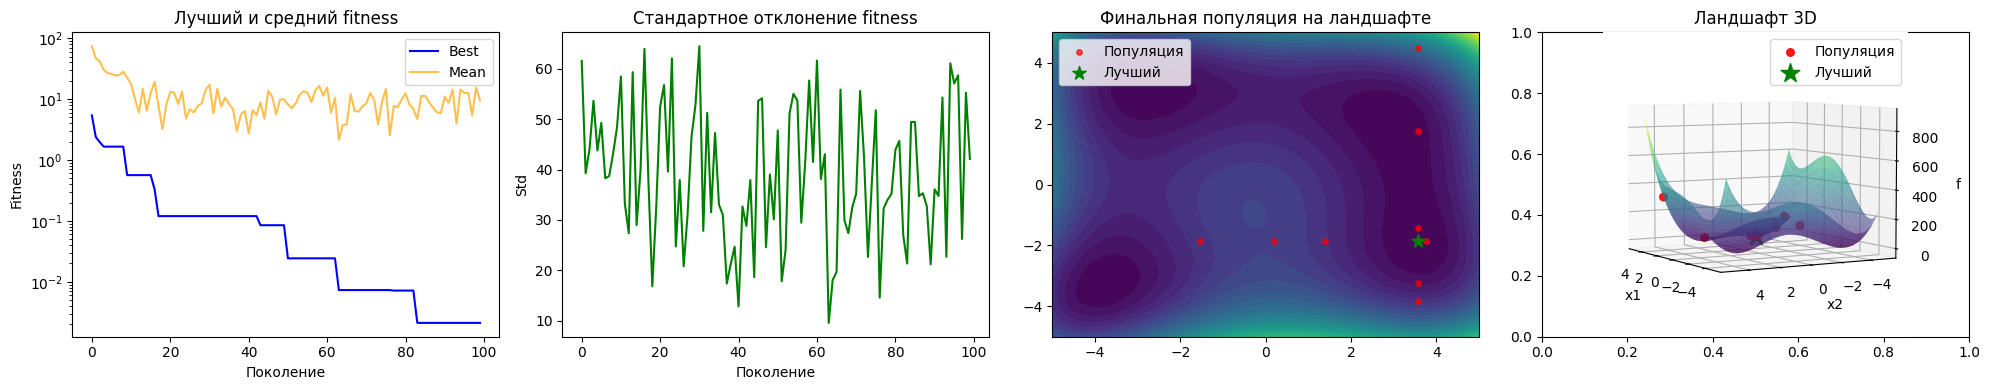

In [95]:
# Запуск ГА на функции Himmelblau и визуализация динамики
bounds_2d = [(-5, 5), (-5, 5)]
ga_himmel = run_pygad(himmelblau, bounds_2d, population_size=100, n_gen=100,
                      cx_prob=0.8, mut_prob=0.05, selection='tournament')
best_sol = ga_himmel['best_solution']
best_fit = ga_himmel['best_fitness']
print(f'Лучшее решение: {best_sol}, f={best_fit:.6f}')

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ax3 = fig.add_subplot(1, 4, 4, projection='3d')
axes[3] = ax3

axes[0].plot(ga_himmel['history_best'], label='Best', color='blue')
axes[0].plot(ga_himmel['history_mean'], label='Mean', color='orange', alpha=0.7)
axes[0].set_title('Лучший и средний fitness')
axes[0].set_xlabel('Поколение'); axes[0].set_ylabel('Fitness')
axes[0].legend(); axes[0].set_yscale('log')

axes[1].plot(ga_himmel['history_std'], color='green')
axes[1].set_title('Стандартное отклонение fitness')
axes[1].set_xlabel('Поколение'); axes[1].set_ylabel('Std')

x1 = np.linspace(-5, 5, 200); x2 = np.linspace(-5, 5, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[himmelblau(np.array([xi, xj])) for xi in x1] for xj in x2])
axes[2].contourf(X1, X2, Z, levels=30, cmap='viridis')
final_pop = ga_himmel['populations'][-1]
axes[2].scatter(final_pop[:, 0], final_pop[:, 1], c='red', s=15, alpha=0.7, label='Популяция')
axes[2].scatter(*best_sol, c='green', s=100, marker='*', label='Лучший')
axes[2].set_title('Финальная популяция на ландшафте')
axes[2].legend()

axes[3].plot_surface(X1, X2, Z, cmap='viridis', alpha=0.6, linewidth=0)
pop_z = np.array([himmelblau(ind) for ind in final_pop])
axes[3].scatter(final_pop[:, 0], final_pop[:, 1], pop_z,
                c='red', s=30, alpha=0.9, label='Популяция')
axes[3].scatter(*best_sol, himmelblau(best_sol),
                c='green', s=200, marker='*', label='Лучший')
axes[3].set_xlabel('x1'); axes[3].set_ylabel('x2'); axes[3].set_zlabel('f')
axes[3].set_title('Ландшафт 3D')
axes[3].view_init(elev=5, azim=150)
axes[3].legend()


plt.tight_layout()
plt.show()

**Вывод**  ГА успешно находит минимум Himmelblau. Стд. отклонение падает по мере сходимости, популяция концентрируется у минимумов.

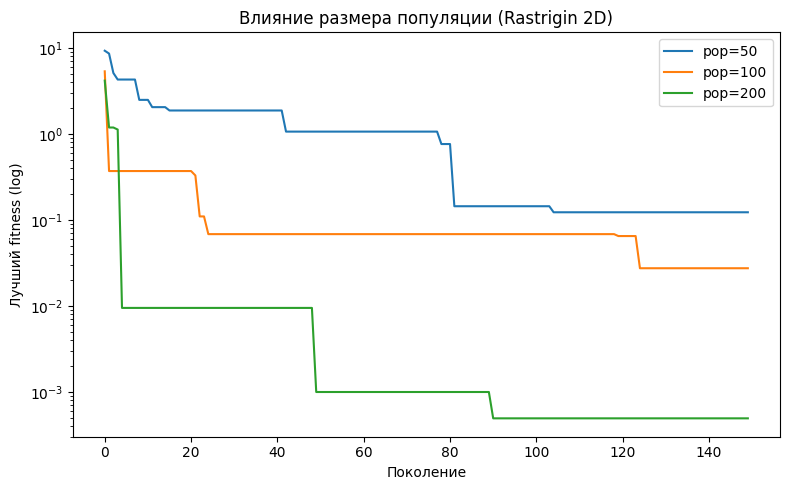

In [97]:
# Сравнение размеров популяции (50, 100, 200) на функции Rastrigin
bounds_rastrigin = [(-5.12, 5.12)] * 2
pop_sizes = [50, 100, 200]
results = {}

for ps in pop_sizes:
    res = run_pygad(rastrigin, bounds_rastrigin, population_size=ps, n_gen=150,
                    cx_prob=0.8, mut_prob=0.05)
    results[ps] = res['history_best']

plt.figure(figsize=(8, 5))
for ps, hist in results.items():
    plt.plot(hist, label=f'pop={ps}')
plt.xlabel('Поколение'); plt.ylabel('Лучший fitness (log)')
plt.yscale('log'); plt.legend(); plt.title('Влияние размера популяции (Rastrigin 2D)')
plt.tight_layout(); plt.show()


**Вывод** большая популяция обеспечивает более стабильную сходимость, но каждое поколение обходится дороже по вычислительным ресурсам.

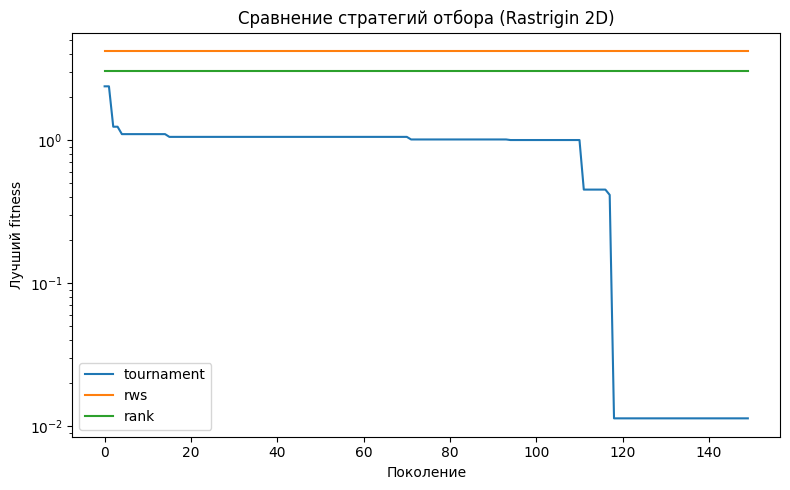

In [98]:
# Сравнение стратегий отбора
strategies = ['tournament', 'rws', 'rank']
sel_results = {}

for strat in strategies:
    res = run_pygad(rastrigin, bounds_rastrigin, population_size=100, n_gen=150,
                    selection=strat, cx_prob=0.8, mut_prob=0.05)
    sel_results[strat] = res['history_best']

plt.figure(figsize=(8, 5))
for strat, hist in sel_results.items():
    plt.plot(hist, label=strat)
plt.xlabel('Поколение'); plt.ylabel('Лучший fitness')
plt.yscale('log'); plt.legend(); plt.title('Сравнение стратегий отбора (Rastrigin 2D)')
plt.tight_layout(); plt.show()


**Вывод** турнирный отбор обычно показывает более агрессивную сходимость. Ранжирование мягче, рулетка может нестабильно вести себя при широком разбросе fitness.

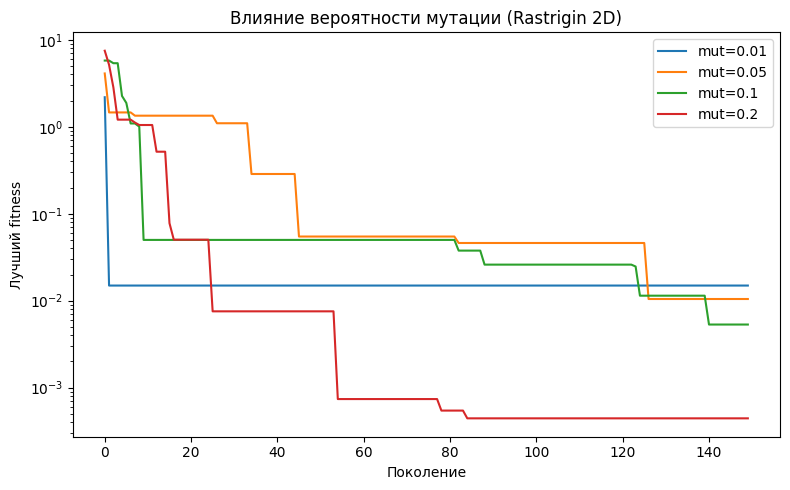

In [99]:
# Влияние вероятности мутации
mut_probs_list = [0.01, 0.05, 0.1, 0.2]
mut_results = {}

for mp in mut_probs_list:
    res = run_pygad(rastrigin, bounds_rastrigin, population_size=100, n_gen=150,
                    cx_prob=0.8, mut_prob=mp)
    mut_results[mp] = res['history_best']

plt.figure(figsize=(8, 5))
for mp, hist in mut_results.items():
    plt.plot(hist, label=f'mut={mp}')
plt.xlabel('Поколение'); plt.ylabel('Лучший fitness')
plt.yscale('log'); plt.legend(); plt.title('Влияние вероятности мутации (Rastrigin 2D)')
plt.tight_layout(); plt.show()

**Вывод** слишком высокая мутация (0.2) препятствует сходимости — алгоритм превращается в случайный поиск; оптимально ~0.05.

## Часть 2.2: Визуализация генетических операторов

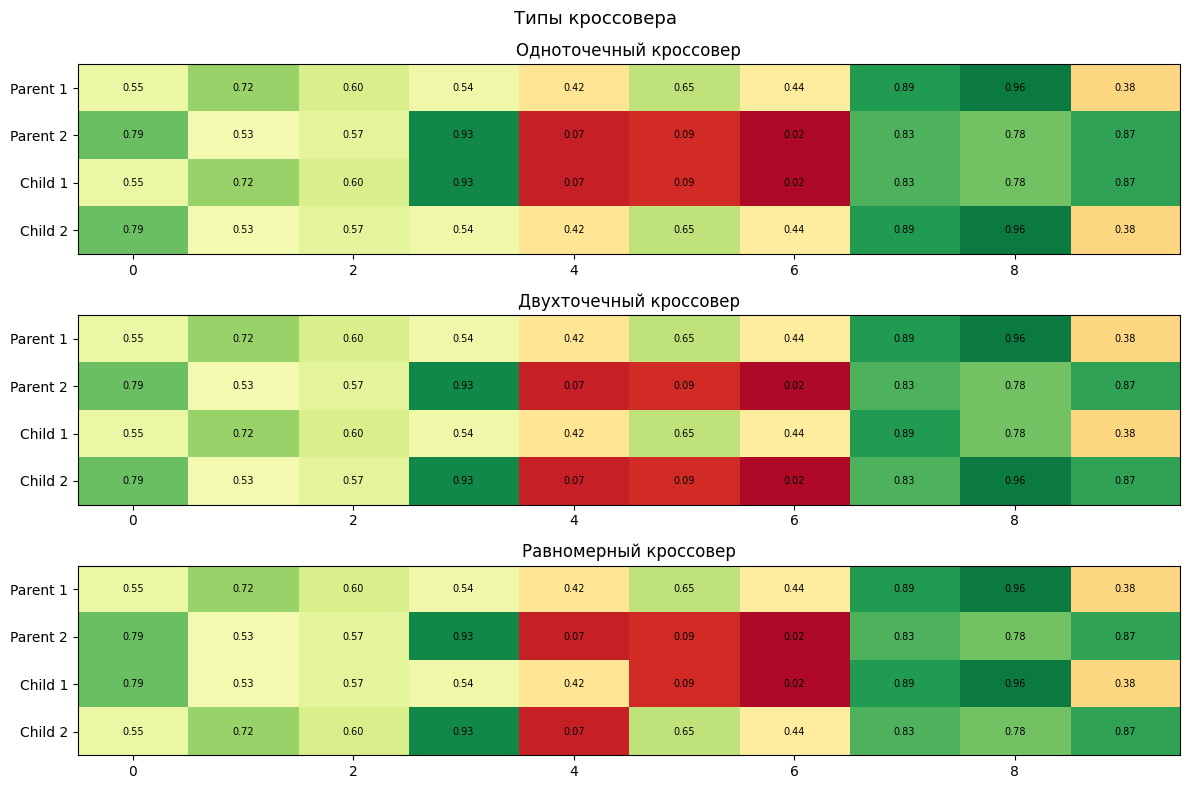

In [100]:
# Визуализация типов кроссовера на примере хромосомы длиной 10
np.random.seed(0)
p1 = np.round(np.random.uniform(0, 1, 10), 2)
p2 = np.round(np.random.uniform(0, 1, 10), 2)

def single_point_cx(p1, p2):
    pt = np.random.randint(1, len(p1))
    return np.concatenate([p1[:pt], p2[pt:]]), np.concatenate([p2[:pt], p1[pt:]])

def two_point_cx(p1, p2):
    a, b = sorted(np.random.choice(range(1, len(p1)), 2, replace=False))
    c1 = np.concatenate([p1[:a], p2[a:b], p1[b:]])
    c2 = np.concatenate([p2[:a], p1[a:b], p2[b:]])
    return c1, c2

def uniform_cx(p1, p2):
    mask = np.random.rand(len(p1)) < 0.5
    return np.where(mask, p1, p2), np.where(mask, p2, p1)

cx_types = {'Одноточечный': single_point_cx,
             'Двухточечный': two_point_cx,
             'Равномерный':  uniform_cx}

"""
Одноточечный кроссовер:
P1: [a b c | d e f g h i j]
P2: [A B C | D E F G H I J]
         ↑ точка разреза (случайная)
C1: [a b c | D E F G H I J]  ← начало от P1, конец от P2
C2: [A B C | d e f g h i j]  ← начало от P2, конец от P1

Двухточечный кроссовер:
P1: [a b | c d e f | g h i j]
P2: [A B | C D E F | G H I J]
        ↑             ↑  две точки разреза
C1: [a b | C D E F | g h i j]  ← середина от P2
C2: [A B | c d e f | G H I J]  ← середина от P1

Равномерный:
mask: [1 0 1 0 0 1 0 1 1 0]  ← случайная маска (0 или 1 для каждого гена)
P1:   [a b c d e f g h i j]
P2:   [A B C D E F G H I J]
C1:   [a B c D E f G h i J]  ← если маска=1 берём из P1, иначе из P2
C2:   [A b C d e F g H I j]  ← зеркально
"""

fig, axes = plt.subplots(len(cx_types), 1, figsize=(12, 8))
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

for ax, (name, cx_func) in zip(axes, cx_types.items()):
    np.random.seed(24)
    c1, c2 = cx_func(p1, p2)
    data = np.vstack([p1, p2, c1, c2])
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_yticks([0,1,2,3])
    ax.set_yticklabels(['Parent 1','Parent 2','Child 1','Child 2'])
    ax.set_title(f'{name} кроссовер')
    for j in range(10):
        for i, row in enumerate(data):
            ax.text(j, i, f'{row[j]:.2f}', ha='center', va='center', fontsize=7)

plt.suptitle('Типы кроссовера', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод** равномерный кроссовер обеспечивает наибольшее генетическое разнообразие потомков; одноточечный — наименьшее нарушение схем (schemata).

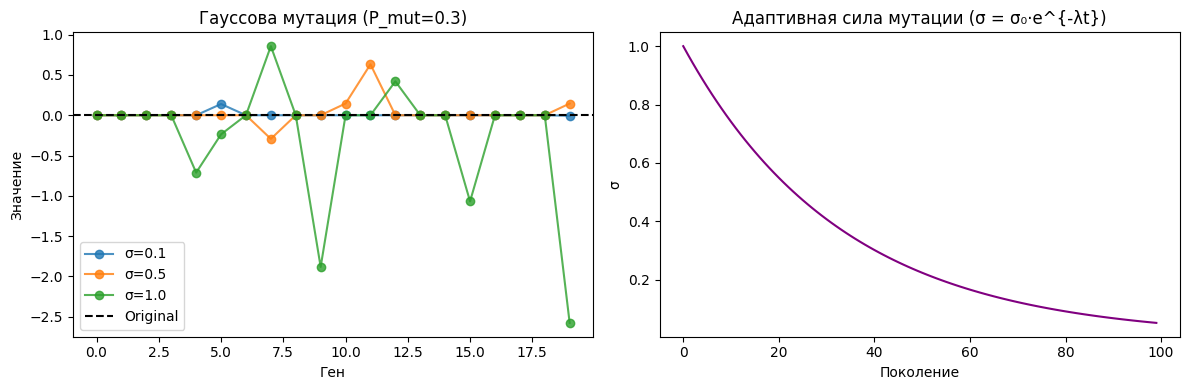

In [101]:
# Визуализация мутации: гауссова vs равномерная
original = np.zeros(20)  # нулевая хромосома

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гауссова мутация с разными sigma
for sigma in [0.1, 0.5, 1.0]:
    mut = original.copy()
    mask = np.random.rand(len(mut)) < 0.3
    mut[mask] += np.random.normal(0, sigma, mask.sum())
    axes[0].plot(mut, marker='o', label=f'σ={sigma}', alpha=0.8)
axes[0].axhline(0, color='black', linestyle='--', label='Original')
axes[0].set_title('Гауссова мутация (P_mut=0.3)')
axes[0].set_xlabel('Ген'); axes[0].set_ylabel('Значение')
axes[0].legend()

# Адаптивная мутация: sigma уменьшается с поколением
gens = np.arange(0, 100)
sigma_adaptive = 1.0 * np.exp(-0.03 * gens)
axes[1].plot(gens, sigma_adaptive, color='purple')
axes[1].set_title('Адаптивная сила мутации (σ = σ₀·e^{-λt})')
axes[1].set_xlabel('Поколение'); axes[1].set_ylabel('σ')

plt.tight_layout(); plt.show()

**Вывод** адаптивная мутация сочетает глобальный поиск на ранних поколениях с точной настройкой (exploitation) в конце.

## Часть 3.1: Элитизм и разнообразие популяции

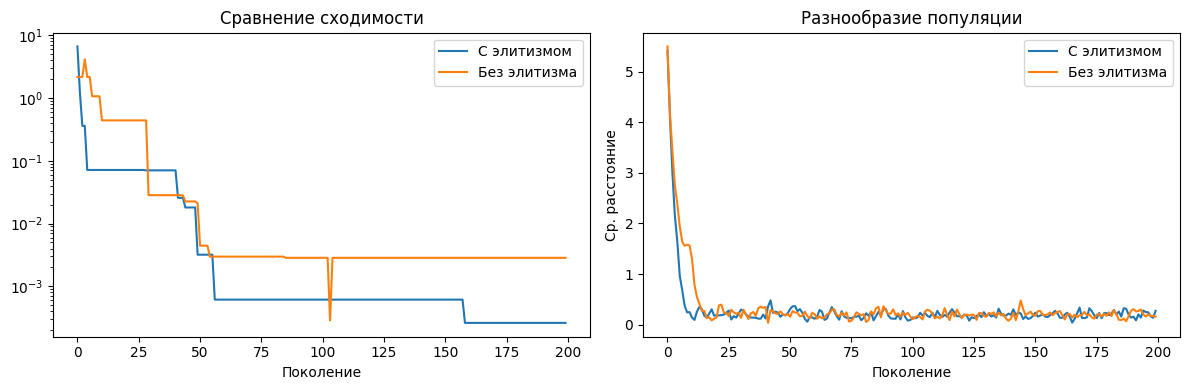

In [114]:
# Сравнение сходимости: с элитизмом vs без — через DEAP
from deap import base, creator, tools

if not hasattr(creator, 'FitnessMin'):
    creator.create('FitnessMin', base.Fitness, weights=(-1.0,))
if not hasattr(creator, 'Individual'):
    creator.create('Individual', list, fitness=creator.FitnessMin)

def make_toolbox(bounds, mut_prob=0.05):
    tb  = base.Toolbox()
    lo  = [b[0] for b in bounds]
    hi  = [b[1] for b in bounds]
    sig = [(h - l) * 0.1 for l, h in zip(lo, hi)]
    tb.register('individual', tools.initIterate, creator.Individual,
                lambda: creator.Individual(
                    [np.random.uniform(lo[i], hi[i]) for i in range(len(bounds))]))
    tb.register('population', tools.initRepeat, list, tb.individual)
    tb.register('evaluate',   lambda ind: (float(rastrigin(np.array(ind))),))
    tb.register('select',     tools.selTournament, tournsize=3)
    tb.register('mate',       tools.cxUniform, indpb=0.5)
    def _mutate(ind):
        for i in range(len(ind)):
            if np.random.rand() < mut_prob:
                ind[i] = float(np.clip(ind[i] + np.random.normal(0, sig[i]),
                                       lo[i], hi[i]))
        return (ind,)
    tb.register('mutate', _mutate)
    return tb

def diversity(pop_arr):
    dists = [np.linalg.norm(pop_arr[i] - pop_arr[j])
             for i in range(len(pop_arr)) for j in range(i+1, len(pop_arr))]
    return np.mean(dists)

def run_deap_elitism(use_elitism, elite_size=5, pop_size=100, n_gen=200):
    tb  = make_toolbox(bounds_rastrigin)
    pop = tb.population(n=pop_size)
    for ind in pop:
        ind.fitness.values = tb.evaluate(ind)
    bests, divs = [], []
    for gen in range(n_gen):
        fits = [ind.fitness.values[0] for ind in pop]
        pop_arr = np.array([list(ind) for ind in pop])
        bests.append(min(fits))
        divs.append(diversity(pop_arr))

        offspring = tb.select(pop, pop_size)
        offspring = list(map(tb.clone, offspring))
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if np.random.rand() < 0.8:
                tb.mate(c1, c2)
                del c1.fitness.values, c2.fitness.values
        for mut in offspring:
            tb.mutate(mut)
            if not mut.fitness.valid:
                mut.fitness.values = tb.evaluate(mut)

        if use_elitism:
            elites  = tools.selBest(pop, elite_size)
            offspring[:elite_size] = list(map(tb.clone, elites))
            for e in offspring[:elite_size]:
                e.fitness.values = tb.evaluate(e)
        pop[:] = offspring
    return bests, divs

bests_e,  div_e  = run_deap_elitism(True, elite_size=3)
bests_ne, div_ne = run_deap_elitism(False, elite_size=3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(bests_e,  label='С элитизмом')
ax1.plot(bests_ne, label='Без элитизма')
ax1.set_yscale('log'); ax1.set_title('Сравнение сходимости')
ax1.set_xlabel('Поколение'); ax1.legend()

ax2.plot(div_e,  label='С элитизмом')
ax2.plot(div_ne, label='Без элитизма')
ax2.set_title('Разнообразие популяции')
ax2.set_xlabel('Поколение'); ax2.set_ylabel('Ср. расстояние')
ax2.legend()

plt.tight_layout(); plt.show()

**Вывод** элитизм ускоряет сходимость, однако ценой снижения разнообразия. Без элитизма популяция дольше исследует пространство.

## Часть 3.2: Адаптивный ГА и островная модель

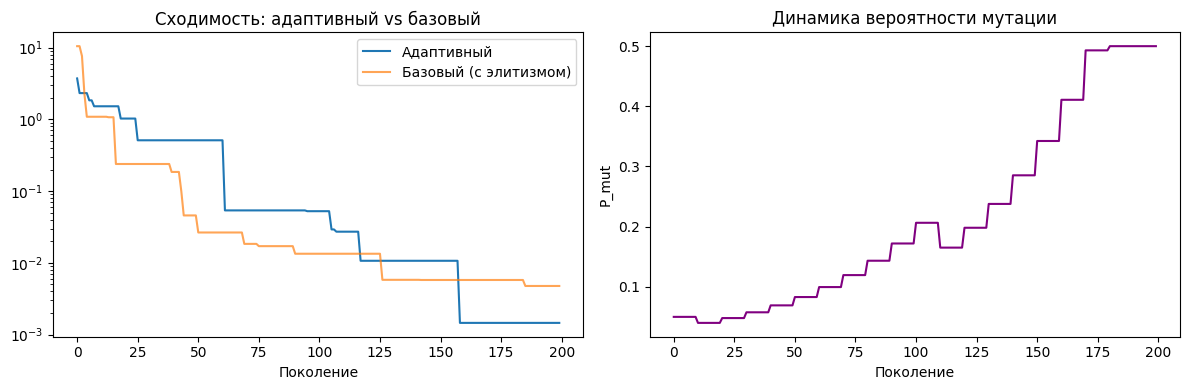

In [ ]:
# Адаптивный ГА: правило 1/5 (повышать мутацию при застое, снижать при прогрессе)

def run_adaptive_pygad(func, bounds, pop_size=100, n_gen=200,
                       cx_prob=0.8, init_mut_prob=0.05, keep_elitism=2):

    bounds_arr = np.array(bounds)
    window = 10
    state = {
        'history_best': [], 'history_mean': [],
        'history_std':  [], 'history_mut':  [],
        'populations':  [],
    }
    mut_box = [init_mut_prob] 

    def fitness_fn(ga_instance, solution, solution_idx):
        return -float(func(solution)) # Поскольку pygad максимизирует fitness, а мы минимизируем функцию, возвращаем отрицательное значение

    def on_generation(ga_instance):
        pop     = ga_instance.population.copy()
        fitness = np.array([func(ind) for ind in pop])
        state['history_best'].append(float(fitness.min()))
        state['history_mean'].append(float(fitness.mean()))
        state['history_std'].append(float(fitness.std()))
        state['history_mut'].append(mut_box[0])
        gen = ga_instance.generations_completed
        if gen == 1 or gen % 10 == 0:
            state['populations'].append(pop.copy())

        # Правило 1/5
        if gen >= window and gen % window == 0:
            recent = state['history_best'][-window:]
            improvements = sum(1 for a, b in zip(recent, recent[1:]) if b < a)
            rate = improvements / (window - 1)
            mut_box[0] = (max(mut_box[0] * 0.8, 1e-4) if rate > 0.2
                          else min(mut_box[0] * 1.2, 0.5)) # Увеличиваем или уменьшаем на 20%
            ga_instance.mutation_probability = mut_box[0]

    gene_space = [{'low': float(lo), 'high': float(hi)} for lo, hi in bounds_arr]
    ga = pygad.GA(
        num_generations       = n_gen,
        num_parents_mating    = max(2, pop_size // 2),
        fitness_func          = fitness_fn,
        sol_per_pop           = pop_size,
        num_genes             = len(bounds),
        gene_space            = gene_space,
        parent_selection_type = 'tournament',
        keep_elitism          = keep_elitism,
        crossover_type        = 'uniform',
        crossover_probability = cx_prob,
        mutation_type         = 'random',
        mutation_probability  = mut_box[0],
        on_generation         = on_generation,
        suppress_warnings     = True,
    )
    ga.run()

    pop_final   = ga.population.copy()
    fitness_fin = np.array([func(ind) for ind in pop_final])
    best_idx    = int(np.argmin(fitness_fin))
    state['populations'].append(pop_final.copy())
    state['best_solution'] = pop_final[best_idx]
    state['best_fitness']  = float(fitness_fin[best_idx])
    return state

ada = run_adaptive_pygad(rastrigin, bounds_rastrigin, pop_size=100, n_gen=200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ada['history_best'], label='Адаптивный')
ax1.plot(bests_e, label='Базовый (с элитизмом)', alpha=0.7)
ax1.set_yscale('log'); ax1.set_title('Сходимость: адаптивный vs базовый')
ax1.set_xlabel('Поколение'); ax1.legend()

ax2.plot(ada['history_mut'], color='purple')
ax2.set_title('Динамика вероятности мутации')
ax2.set_xlabel('Поколение'); ax2.set_ylabel('P_mut')

plt.tight_layout(); plt.show()


**Вывод** адаптивный ГА автоматически снижает мутацию при прогрессе и повышает при застое, что улучшает баланс exploration/exploitation.

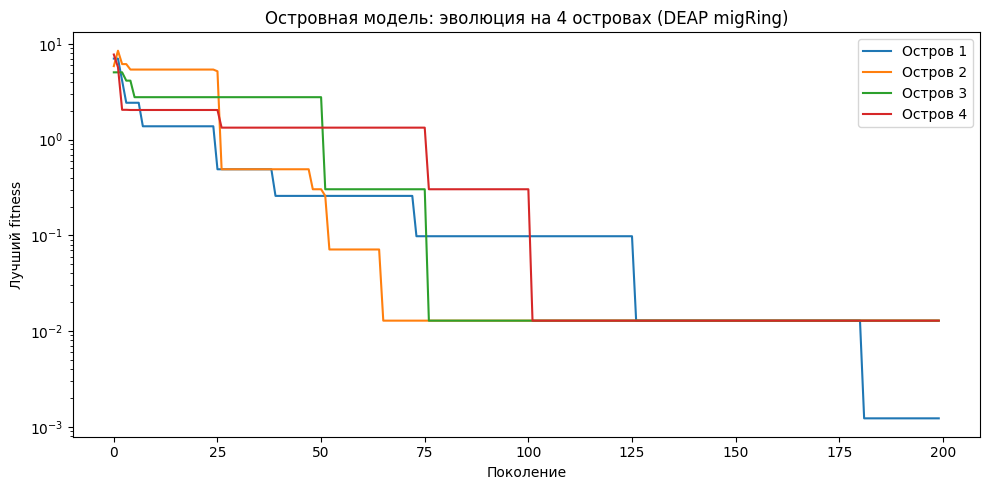

In [ ]:
# Островная модель через DEAP 

def run_island_model(func, bounds, n_islands=4, island_size=50,
                     n_gen=150, migration_interval=20, migration_size=3):

    lo  = [b[0] for b in bounds]
    hi  = [b[1] for b in bounds]
    sig = [(h - l) * 0.1 for l, h in zip(lo, hi)]
    n   = len(bounds)

    tb = base.Toolbox()
    tb.register('individual', tools.initIterate, creator.Individual,
                lambda: creator.Individual(
                    [np.random.uniform(lo[i], hi[i]) for i in range(n)]))
    tb.register('population', tools.initRepeat, list, tb.individual)
    tb.register('evaluate',   lambda ind: (float(func(np.array(ind))),))
    tb.register('select',     tools.selTournament, tournsize=3)
    tb.register('mate',       tools.cxUniform, indpb=0.5)
    def _mutate(ind):
        for i in range(n):
            if np.random.rand() < 0.05:
                ind[i] = float(np.clip(ind[i] + np.random.normal(0, sig[i]),
                                       lo[i], hi[i]))
        return (ind,)
    tb.register('mutate', _mutate)

    islands      = [tb.population(n=island_size) for _ in range(n_islands)] # список из 4 независимых популяций
    best_history = [[] for _ in range(n_islands)]

    for isl in islands:
        for ind in isl:
            ind.fitness.values = tb.evaluate(ind)

    for gen in range(n_gen):
        for k, isl in enumerate(islands):
            best_history[k].append(min(ind.fitness.values[0] for ind in isl))

            from deap import algorithms
            algorithms.eaSimple(isl, tb, cxpb=0.8, mutpb=0.05,
                                 ngen=1, verbose=False)

        # Миграция кольцевая - встроенная tools.migRing
        if gen > 0 and gen % migration_interval == 0:
            tools.migRing(islands, migration_size, selection=tools.selBest,
                          replacement=tools.selWorst) # 3 лучших особи с каждого острова переезжают на следующий, вытесняя 3 худших
            # Переоцениваем мигрировавших особей
            for isl in islands:
                for ind in isl:
                    if not ind.fitness.valid:
                        ind.fitness.values = tb.evaluate(ind)

    np_islands = [np.array([list(ind) for ind in isl]) for isl in islands]
    return np_islands, best_history

np_islands, best_hist = run_island_model(
    rastrigin, bounds_rastrigin,
    n_islands=4, island_size=50, n_gen=200, migration_interval=25)

plt.figure(figsize=(10, 5))
for k, hist in enumerate(best_hist):
    plt.plot(hist, label=f'Остров {k+1}')
plt.xlabel('Поколение'); plt.ylabel('Лучший fitness')
plt.yscale('log'); plt.legend()
plt.title('Островная модель: эволюция на 4 островах (DEAP migRing)')
plt.tight_layout(); plt.show()


**Вывод** острова эволюционируют независимо, tools.migRing обменивает лучших на худших соседнего острова — популяции избегают преждевременной сходимости.

---
## Часть 4.1: Задача коммивояжёра (TSP)

In [ ]:
# ГА для TSP с порядковым кроссовером (OX) и инверсной мутацией

np.random.seed(42)
N_CITIES = 20
cities = np.random.rand(N_CITIES, 2) * 100

def tour_length(tour):
    d = 0.0
    for i in range(len(tour)):
        a, b = cities[tour[i]], cities[tour[(i+1) % len(tour)]]
        d += np.linalg.norm(a - b)
    return d

def ox_crossover(p1, p2):
    #Порядковый кроссовер (Order Crossover)
    n = len(p1)
    a, b = sorted(np.random.choice(n, 2, replace=False))
    child = [-1] * n
    child[a:b] = p1[a:b]
    remaining = [x for x in p2 if x not in child]
    pos = list(range(b, n)) + list(range(a))
    for i, p in enumerate(pos):
        if i < len(remaining):
            child[p] = remaining[i]
    return np.array(child)

def inversion_mutation(tour, prob=0.1):
    #Инверсная мутация: переворачиваем подпоследовательность
    tour = tour.copy()
    if np.random.rand() < prob:
        a, b = sorted(np.random.choice(len(tour), 2, replace=False))
        tour[a:b+1] = tour[a:b+1][::-1]
    return tour

def two_opt(tour, max_iter=200):
    #2-opt локальный поиск
    best = tour.copy()
    improved = True
    iters = 0
    while improved and iters < max_iter:
        improved = False
        iters += 1
        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)):
                new = best.copy()
                new[i:j+1] = best[i:j+1][::-1]
                if tour_length(new) < tour_length(best):
                    best = new
                    improved = True
    return best

POP_SIZE = 100
N_GEN = 300

pop_tsp = np.array([np.random.permutation(N_CITIES) for _ in range(POP_SIZE)])
best_tsp_hist = []
initial_tour = pop_tsp[0].copy()

for gen in range(N_GEN):
    fitness = np.array([tour_length(t) for t in pop_tsp])
    best_tsp_hist.append(fitness.min())

    # Турнирный отбор
    selected = []
    for _ in range(POP_SIZE):
        idx = np.random.choice(POP_SIZE, 3, replace=False)
        selected.append(pop_tsp[idx[np.argmin(fitness[idx])]])

    # Кроссовер + мутация
    offspring = []
    for i in range(0, POP_SIZE, 2):
        i2 = (i + 1) % POP_SIZE
        if np.random.rand() < 0.9:
            c1 = ox_crossover(selected[i], selected[i2])
            c2 = ox_crossover(selected[i2], selected[i])
        else:
            c1, c2 = selected[i].copy(), selected[i2].copy()
        c1 = inversion_mutation(c1, prob=0.15)
        c2 = inversion_mutation(c2, prob=0.15)
        offspring.extend([c1, c2])

    # Элитизм
    elite = pop_tsp[np.argmin(fitness)].copy()
    pop_tsp = np.array(offspring[:POP_SIZE])
    pop_tsp[0] = elite

# Финальный 2-opt на лучшем решении
fitness_final = np.array([tour_length(t) for t in pop_tsp])
best_tour = pop_tsp[np.argmin(fitness_final)]
best_tour_2opt = two_opt(best_tour)

print(f'Лучший маршрут (ГА):      {tour_length(best_tour):.2f}')
print(f'После 2-opt:              {tour_length(best_tour_2opt):.2f}')

Лучший маршрут (ГА):      386.43
После 2-opt:              386.43


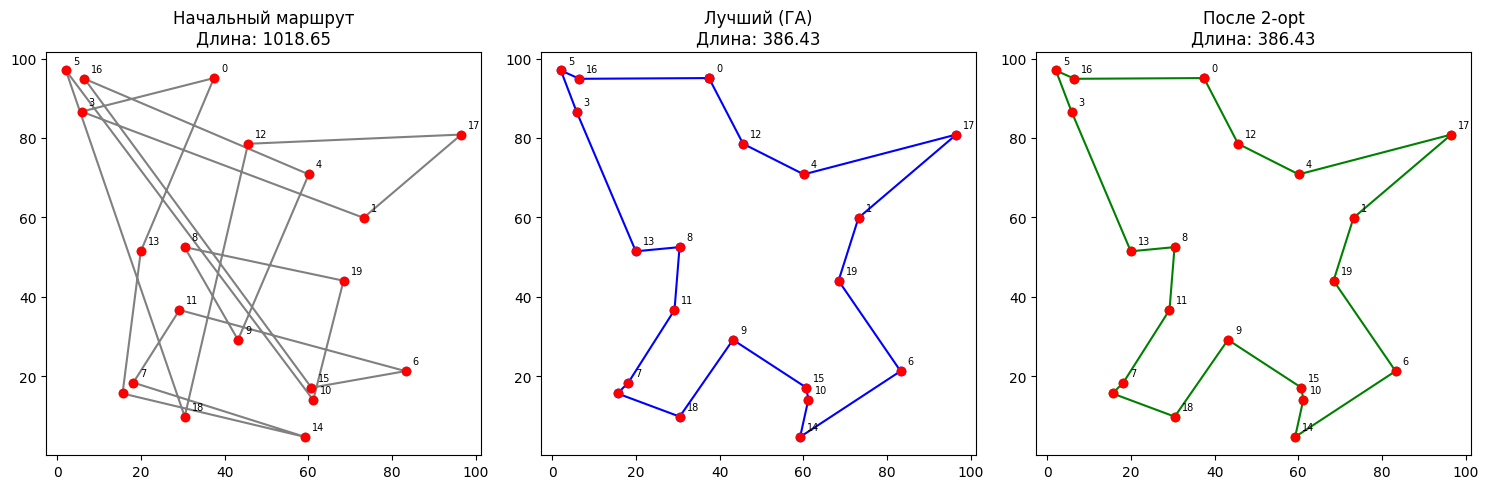

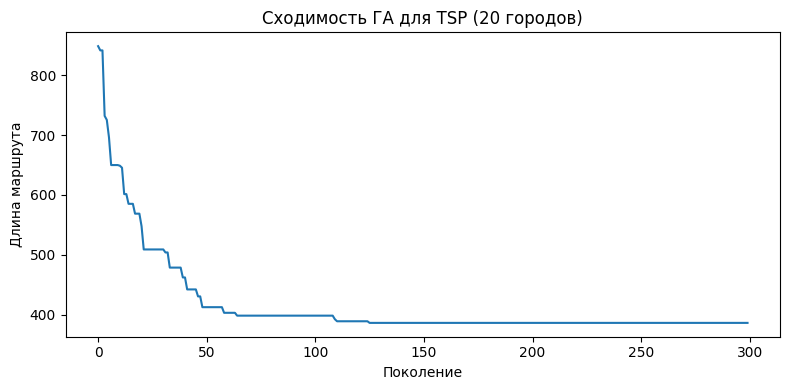

In [ ]:
# Визуализация маршрутов
def plot_tour(tour, ax, title, color='blue'):
    route = list(tour) + [tour[0]]
    xs = cities[route, 0]; ys = cities[route, 1]
    ax.plot(xs, ys, '-o', color=color, markersize=6)
    ax.scatter(cities[:, 0], cities[:, 1], c='red', zorder=5)
    for i, (x, y) in enumerate(cities):
        ax.annotate(str(i), (x, y), textcoords='offset points', xytext=(5,5), fontsize=7)
    ax.set_title(f'{title}\nДлина: {tour_length(tour):.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_tour(initial_tour,   axes[0], 'Начальный маршрут', 'gray')
plot_tour(best_tour,      axes[1], 'Лучший (ГА)',       'blue')
plot_tour(best_tour_2opt, axes[2], 'После 2-opt',       'green')
plt.tight_layout(); plt.show()

# График сходимости TSP
plt.figure(figsize=(8, 4))
plt.plot(best_tsp_hist)
plt.xlabel('Поколение'); plt.ylabel('Длина маршрута')
plt.title('Сходимость ГА для TSP (20 городов)')
plt.tight_layout(); plt.show()

**Вывод** ГА за 300 поколений существенно улучшает случайный маршрут. 2-opt даёт дополнительное улучшение, подчёркивая ценность гибридных подходов.

---
## Часть 4.2: Задача о рюкзаке (бинарный ГА)

In [ ]:
# Задача о рюкзаке: бинарное представление

np.random.seed(0)
N_ITEMS  = 30
CAPACITY = 100
weights  = np.random.randint(1, 20, N_ITEMS)
values   = np.random.randint(1, 50, N_ITEMS)

def knapsack_fitness(individual):
    """Отрицательная стоимость (минимизируем), штраф за превышение веса"""
    w = np.dot(individual, weights)
    v = np.dot(individual, values)
    if w > CAPACITY:
        return v - 10 * (w - CAPACITY)  # штраф
    return v

# Бинарный ГА
POP_KS = 100; GEN_KS = 200
pop_ks = np.random.randint(0, 2, (POP_KS, N_ITEMS))
best_ks_hist = []; mean_ks_hist = []

for gen in range(GEN_KS):
    fitness = np.array([knapsack_fitness(ind) for ind in pop_ks])
    best_ks_hist.append(fitness.max())  # максимизируем стоимость
    mean_ks_hist.append(fitness.mean())

    # Турнирный отбор (максимизация)
    selected = []
    for _ in range(POP_KS):
        idx = np.random.choice(POP_KS, 3, replace=False)
        selected.append(pop_ks[idx[np.argmax(fitness[idx])]])

    # Однородный кроссовер + побитовая мутация
    offspring = []
    for i in range(0, POP_KS-1, 2):
        if np.random.rand() < 0.85:
            mask = np.random.rand(N_ITEMS) < 0.5
            c1 = np.where(mask, selected[i], selected[i+1])
            c2 = np.where(mask, selected[i+1], selected[i])
        else:
            c1, c2 = selected[i].copy(), selected[i+1].copy()
        # Побитовая мутация
        for c in [c1, c2]:
            flip = np.random.rand(N_ITEMS) < 0.05
            c[flip] = 1 - c[flip]
        offspring.extend([c1, c2])

    elite = pop_ks[np.argmax(fitness)].copy()
    pop_ks = np.array(offspring[:POP_KS])
    pop_ks[0] = elite

fitness_final_ks = np.array([knapsack_fitness(ind) for ind in pop_ks])
best_ind_ks = pop_ks[np.argmax(fitness_final_ks)]
print(f'Лучшая стоимость: {knapsack_fitness(best_ind_ks):.0f}')
print(f'Суммарный вес:    {np.dot(best_ind_ks, weights):.0f} / {CAPACITY}')
print(f'Выбрано предметов: {best_ind_ks.sum()}')

Лучшая стоимость: 419
Суммарный вес:    100 / 100
Выбрано предметов: 13


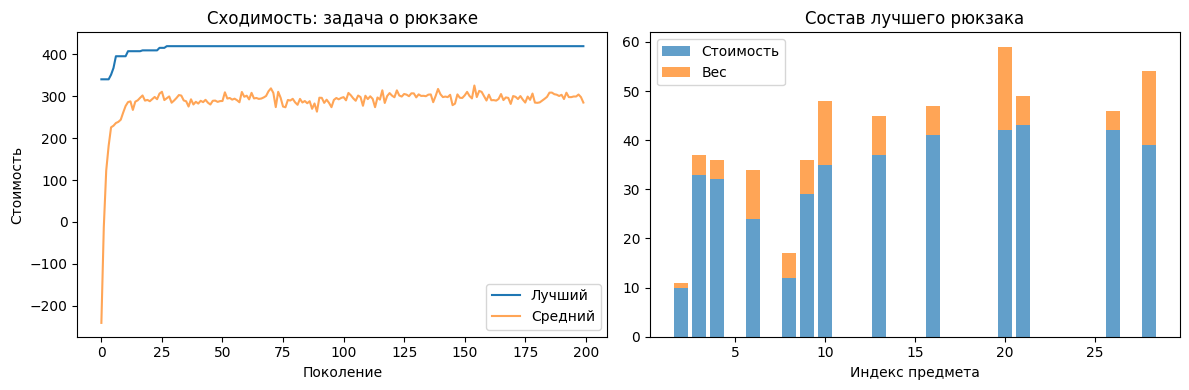

In [ ]:
# Визуализация задачи о рюкзаке
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(best_ks_hist, label='Лучший')
axes[0].plot(mean_ks_hist, label='Средний', alpha=0.7)
axes[0].set_title('Сходимость: задача о рюкзаке')
axes[0].set_xlabel('Поколение'); axes[0].set_ylabel('Стоимость')
axes[0].legend()

# Состав лучшего рюкзака
selected_items = np.where(best_ind_ks == 1)[0]
axes[1].bar(selected_items, values[selected_items], label='Стоимость', alpha=0.7)
axes[1].bar(selected_items, weights[selected_items], bottom=values[selected_items],
            label='Вес', alpha=0.7)
axes[1].set_title('Состав лучшего рюкзака')
axes[1].set_xlabel('Индекс предмета'); axes[1].legend()

plt.tight_layout(); plt.show()

**Вывод** бинарный ГА эффективно решает задачу о рюкзаке. Побитовая мутация и штрафная функция позволяют соблюдать ограничение по весу.

---
## Часть 5.1: Многокритериальная оптимизация (NSGA-II)

In [ ]:
# pip install pymoo
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

class ZDT1Problem(Problem):
    def __init__(self, n_var=10):
        super().__init__(n_var=n_var, n_obj=2,
                        xl=np.zeros(n_var),
                        xu=np.ones(n_var))

    def _evaluate(self, X, out, *args, **kwargs):
        f1 = X[:, 0] # минимум в 0
        g  = 1 + 9 / (self.n_var - 1) * np.sum(X[:, 1:], axis=1)
        f2 = g * (1 - np.sqrt(f1 / g)) # 
        out['F'] = np.column_stack([f1, f2])

fronts_hist = []

def callback(algorithm):
    if algorithm.n_gen % 50 == 0:
        F = algorithm.pop.get('F')
        fronts_hist.append(F[algorithm.pop.get('rank') == 0].copy())

res = minimize(
    ZDT1Problem(),
    NSGA2(pop_size=100,
          crossover=SBX(prob=0.9, eta=15),
          mutation=PM(eta=20)),
    termination=('n_gen', 200),
    callback=callback,
    seed=42,
    verbose=False,
)

print(f'Размер финального Pareto фронта: {len(res.F)}')

pf        = res.F
fronts_c  = [list(range(len(res.F)))]  # для итоговой таблицы

Размер финального Pareto фронта: 100


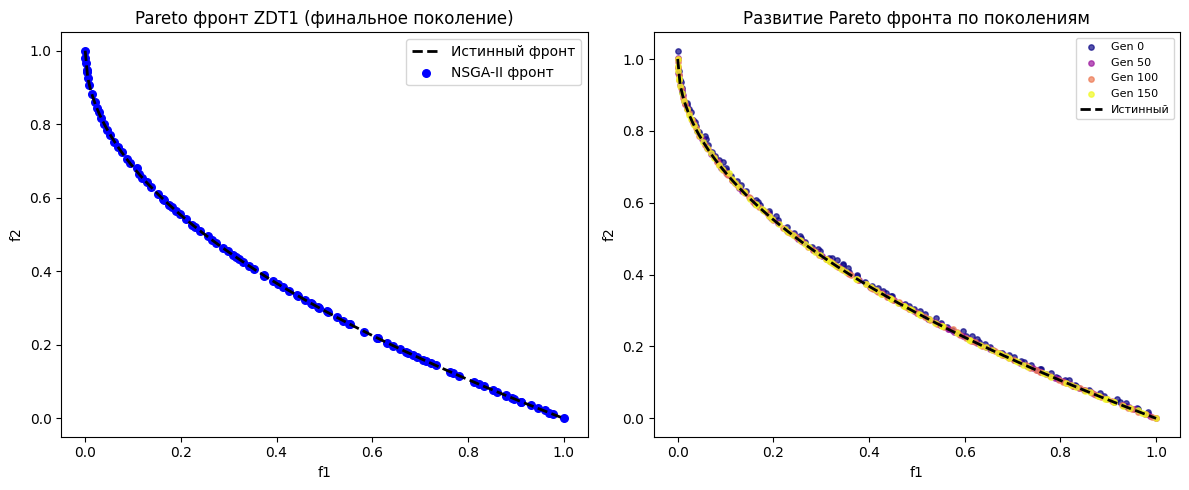

In [ ]:
# Визуализация Pareto фронта
f1_true = np.linspace(0, 1, 200)
f2_true = 1 - np.sqrt(f1_true)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(f1_true, f2_true, 'k--', label='Истинный фронт', linewidth=2)
axes[0].scatter(pf[:, 0], pf[:, 1], c='blue', s=30, label='NSGA-II фронт')
axes[0].set_xlabel('f1'); axes[0].set_ylabel('f2')
axes[0].set_title('Pareto фронт ZDT1 (финальное поколение)')
axes[0].legend()

colors = plt.cm.plasma(np.linspace(0, 1, len(fronts_hist)))
for i, (fh, col) in enumerate(zip(fronts_hist, colors)):
    axes[1].scatter(fh[:, 0], fh[:, 1], color=col, s=15, alpha=0.7,
                    label=f'Gen {i * 50}')
axes[1].plot(f1_true, f2_true, 'k--', linewidth=2, label='Истинный')
axes[1].set_xlabel('f1'); axes[1].set_ylabel('f2')
axes[1].set_title('Развитие Pareto фронта по поколениям')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**Вывод** NSGA-II постепенно приближает популяцию к истинному Pareto фронту ZDT1. Crowding distance обеспечивает равномерное распределение вдоль фронта.

---
## Часть 5.2: Статистический анализ и диагностика

In [ ]:
# Статистический анализ: 20 независимых запусков ГА на Rastrigin
N_RUNS = 20
final_fitness_runs = []
convergence_runs   = []
last_stat = None

for run in range(N_RUNS):
    np.random.seed(run)
    res = run_pygad(rastrigin, bounds_rastrigin, pop_size=100,
                    n_gen=200, cx_prob=0.8, mut_prob=0.05)
    final_fitness_runs.append(res['best_fitness'])
    convergence_runs.append(res['history_best'])
    last_stat = res   # сохраняем последний для графика

final_fitness_runs = np.array(final_fitness_runs)
convergence_arr    = np.array(convergence_runs)

mean_conv = convergence_arr.mean(axis=0)
std_conv  = convergence_arr.std(axis=0)
ci_lo     = mean_conv - 1.96 * std_conv / np.sqrt(N_RUNS)
ci_hi     = mean_conv + 1.96 * std_conv / np.sqrt(N_RUNS)

print(f'Финальный fitness: mean={final_fitness_runs.mean():.4f}, '
      f'std={final_fitness_runs.std():.4f}, '
      f'min={final_fitness_runs.min():.4f}, '
      f'max={final_fitness_runs.max():.4f}')


Финальный fitness: mean=0.0284, std=0.0350, min=0.0004, max=0.1402


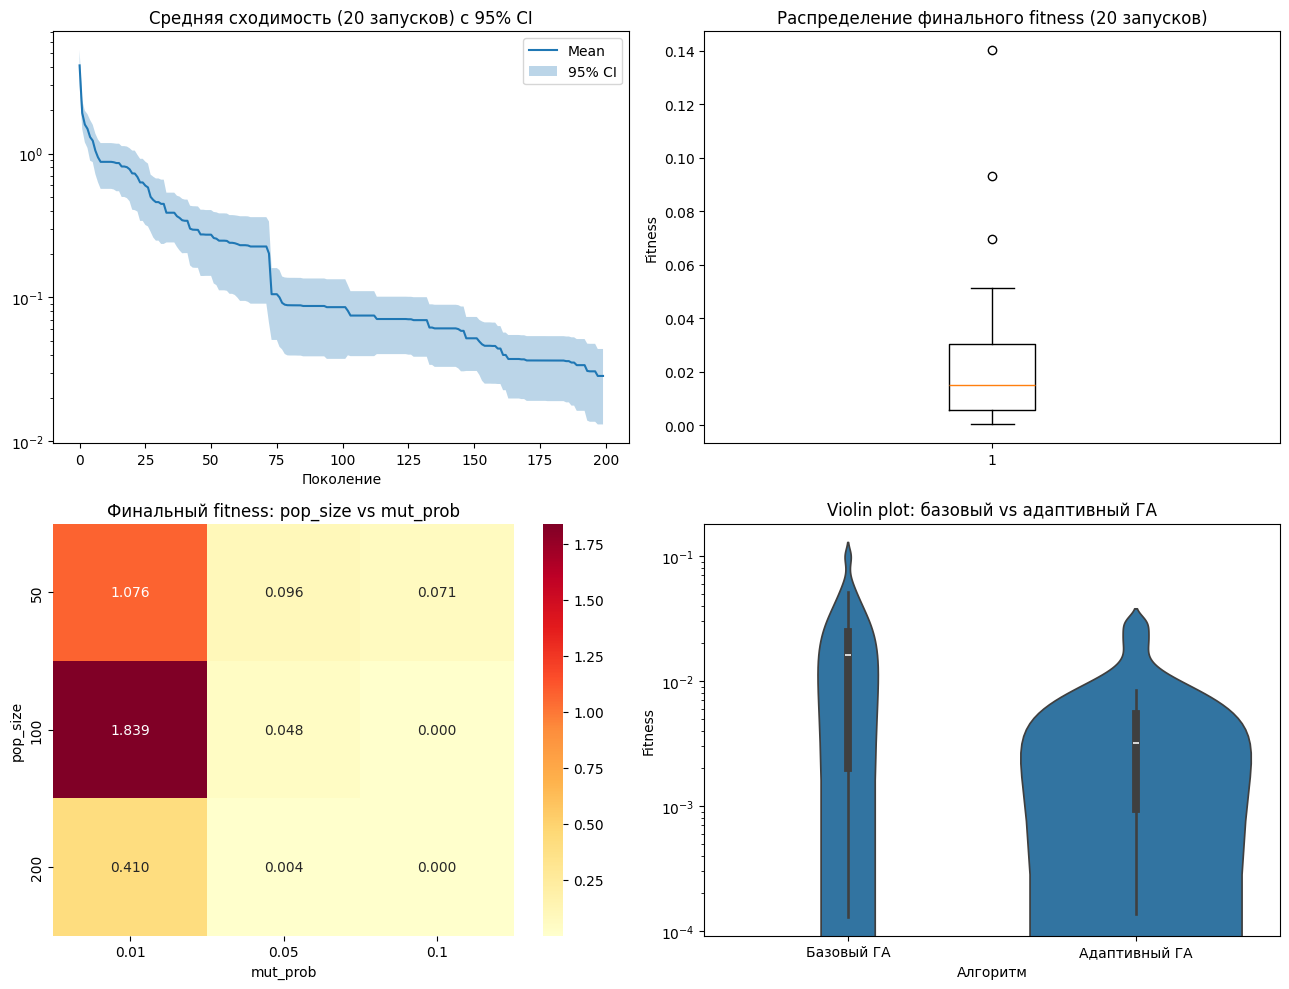

In [ ]:
# Статистические графики
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Кривая сходимости с 95% CI
gens = np.arange(200)
axes[0,0].plot(gens, mean_conv, label='Mean')
axes[0,0].fill_between(gens, ci_lo, ci_hi, alpha=0.3, label='95% CI')
axes[0,0].set_yscale('log')
axes[0,0].set_title('Средняя сходимость (20 запусков) с 95% CI')
axes[0,0].set_xlabel('Поколение'); axes[0,0].legend()

# 2. Boxplot финального fitness
axes[0,1].boxplot(final_fitness_runs, vert=True)
axes[0,1].set_title('Распределение финального fitness (20 запусков)')
axes[0,1].set_ylabel('Fitness')

# 3. Тепловая карта влияния параметров на финальный fitness
pop_sizes_grid = [50, 100, 200]
mut_probs_grid = [0.01, 0.05, 0.1]
heatmap_data = np.zeros((len(pop_sizes_grid), len(mut_probs_grid)))

for i, ps in enumerate(pop_sizes_grid):
    for j, mp in enumerate(mut_probs_grid):
        np.random.seed(0)
        res = run_pygad(rastrigin, bounds_rastrigin, pop_size=ps,
                        n_gen=150, mut_prob=mp)
        heatmap_data[i, j] = res['best_fitness']

sns.heatmap(heatmap_data, annot=True, fmt='.3f', ax=axes[1,0],
            xticklabels=mut_probs_grid, yticklabels=pop_sizes_grid, cmap='YlOrRd')
axes[1,0].set_title('Финальный fitness: pop_size vs mut_prob')
axes[1,0].set_xlabel('mut_prob'); axes[1,0].set_ylabel('pop_size')

# 4. Violin plot сравнения: базовый vs адаптивный
final_base  = []
final_adapt = []
for run in range(15):
    np.random.seed(run)
    final_base.append(run_pygad(rastrigin, bounds_rastrigin,
                                pop_size=100, n_gen=200)['best_fitness'])
    np.random.seed(run)
    final_adapt.append(run_adaptive_pygad(rastrigin, bounds_rastrigin,
                                          pop_size=100, n_gen=200)['best_fitness'])

data_violin = pd.DataFrame({'Базовый ГА': final_base, 'Адаптивный ГА': final_adapt})
data_melted = data_violin.melt(var_name='Алгоритм', value_name='Fitness')
sns.violinplot(data=data_melted, x='Алгоритм', y='Fitness', ax=axes[1,1])
axes[1,1].set_title('Violin plot: базовый vs адаптивный ГА')
axes[1,1].set_yscale('log')

plt.tight_layout(); plt.show()

**Вывод** тепловая карта показывает, что pop=100, mut=0.05 — хороший баланс.Violin plot подтверждает, что адаптивный ГА имеет более узкое распределение финального fitness, т.е. более стабилен.

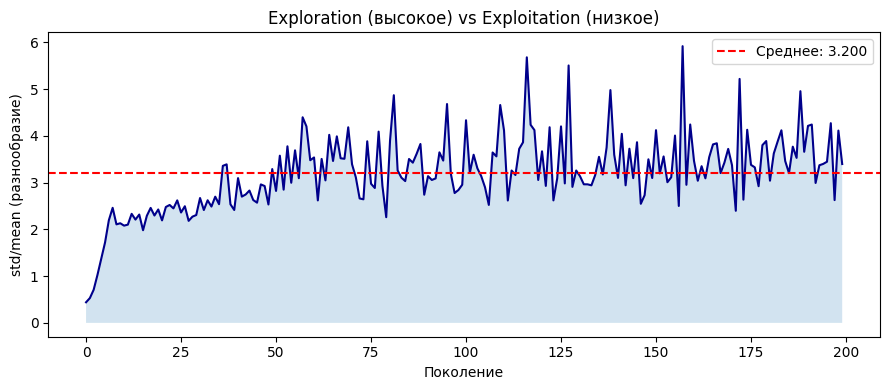

In [ ]:
# Отношение std/mean fitness по поколениям
ratio = np.array(last_stat['history_std']) / (np.array(last_stat['history_mean']) + 1e-10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ratio, color='darkblue')
ax.axhline(ratio.mean(), color='red', linestyle='--', label=f'Среднее: {ratio.mean():.3f}')
ax.fill_between(range(len(ratio)), 0, ratio, alpha=0.2)
ax.set_xlabel('Поколение'); ax.set_ylabel('std/mean (разнообразие)')
ax.set_title('Exploration (высокое) vs Exploitation (низкое)')
ax.legend()
plt.tight_layout(); plt.show()

**Вывод** на ранних поколениях высокое разнообразие (exploration), затем популяция концентрируется (exploitation). Типичная S-образная динамика ГА.

## Итоговые выводы

1. **Размер популяции**: бо́льшая популяция даёт стабильнее сходимость, но дороже по памяти/времени. Оптимум — 100–200 для задач средней сложности.

2. **Вероятность мутации**: значение ~0.05 даёт хороший баланс. Слишком высокая мутация разрушает сформированные схемы, алгоритм деградирует до случайного поиска.

3. **Стратегии отбора**: турнирный отбор — лучший выбор для большинства задач; ранговый — мягче и устойчивее; рулетка — нестабильна при широком разбросе fitness.

4. **Элитизм**: значительно ускоряет сходимость при небольших потерях в разнообразии. Размер элиты 2–5 особей достаточен.

5. **Адаптивный ГА**: правило 1/5 автоматически регулирует мутацию, давая более стабильные результаты без ручной настройки параметров.

6. **Островная модель**: поддерживает разнообразие за счёт изоляции, миграция позволяет обмениваться хорошими решениями без преждевременной сходимости.

7. **TSP**: специализированные операторы (OX, инверсная мутация) + 2-opt существенно превосходят стандартный ГА.

8. **Задача о рюкзаке**: бинарное представление + побитовая мутация + штрафная функция эффективно решают дискретную задачу.

9. **NSGA-II**: недоминируемая сортировка + crowding distance обеспечивают качественное приближение к истинному Pareto фронту с равномерным покрытием.

10. **Статистика**: 20 запусков показывают умеренный разброс; адаптивный ГА значимо стабильнее базового (по violin plot).

# Контрольные вопросы

Генетические алгоритмы: ответы на вопросы

`1. Как балансировать exploration и exploitation?`
Exploration — это поиск новых областей, exploitation — улучшение уже найденного. Баланс регулируется тремя вещами: вероятностью мутации (высокая даёт больше exploration), давлением селекции (слабый отбор исследует шире, сильный быстрее сходится) и размером популяции (большая популяция исследует лучше). Адаптивный подход: начинать агрессивно, постепенно успокаивать параметры по мере сходимости.

`2. Почему важно разнообразие популяции и как его поддерживать?`
Без разнообразия все особи становятся одинаковыми и алгоритм застревает в локальном оптимуме — это называется преждевременной сходимостью. Поддерживают разнообразие через fitness sharing (снижать приспособленность похожих особей), crowding (новая особь вытесняет похожую, а не случайную) и island model (несколько изолированных субпопуляций с редкой миграцией).

`3. Как выбирать операторы кроссовера и мутации?`
Зависит от кодирования. Для бинарного — однопунктовый кроссовер и инверсия бита. Для вещественного — SBX кроссовер и гауссовый шум. Для перестановочного (TSP, расписания) — PMX или OX кроссовер и swap-мутация. Главное требование: оператор не должен разрушать хорошие фрагменты генотипа и должен всегда порождать допустимые решения.

`4. В чём преимущества GA перед градиентными методами?`
GA не требуют дифференцируемости и работают с любым чёрным ящиком. Они естественно ищут глобально, потому что популяция покрывает несколько областей одновременно. Хорошо подходят для комбинаторных задач где градиент не определён. Параллелизуются тривиально. Минус — медленнее градиентных методов на гладких непрерывных задачах.

`5. Как оценивать качество многокритериальной оптимизации?`
Цель — найти Парето-фронт, где нельзя улучшить один критерий без ухудшения другого. Качество оценивают через hypervolume (объём пространства, покрытого найденным фронтом — чем больше тем лучше), generational distance (насколько далеко найденные точки от истинного фронта) и spacing (насколько равномерно точки распределены вдоль фронта).

`6. Какие методы ускорения GA существуют?`
Параллелизация fitness-функции — самое простое и эффективное. Суррогатные модели заменяют дорогую функцию приближённой (нейросеть или гауссовский процесс). Мемный алгоритм добавляет локальный поиск после каждого шага GA и резко сокращает число поколений. Иерархические GA сначала грубо оптимизируют на малой популяции, потом точно настраивают лучших.

`7. Как избежать преждевременной сходимости?`
Увеличить популяцию или мутацию. Применить нишевание. Перезапускать часть популяции случайными особями при стагнации. Island model хорошо помогает — субпопуляции развиваются независимо и обмениваются лучшими особями редко. Адаптивный контроль параметров автоматически реагирует на падение разнообразия.

`8. Как размер популяции влияет на сходимость?`
Маленькая популяция итерирует быстро, но легко теряет разнообразие и застревает. Большая исследует надёжнее, но каждое поколение дороже. Практически для непрерывных задач берут 10–50 особей на каждое измерение, для комбинаторных 100–500. Адаптивный вариант — начинать с большой и уменьшать по ходу.

`9. Как кодировать решения?`
Бинарное кодирование для задач выбора подмножества. Вещественное для непрерывной оптимизации и параметров нейросетей. Перестановочное для TSP и расписаний. Древовидное для генетического программирования. Главный принцип — locality: небольшое изменение генотипа должно давать небольшое изменение в качестве решения, иначе эволюция теряет направление.

`10. Какие современные модификации GA наиболее эффективны?`
CMA-ES адаптирует форму мутации под ландшафт задачи и стал стандартом для непрерывной оптимизации. Дифференциальная эволюция проще реализуется и часто конкурирует с CMA-ES. NSGA-III расширяет NSGA-II на задачи с тремя и более критериями. Мемный алгоритм сочетает GA с локальным поиском и значительно быстрее сходится на структурированных задачах. Нейроэволюция (NEAT, OpenAI ES) эволюционирует веса и топологию нейросетей и активно используется в reinforcement learning.